# Lab 2: Ensembles of Trees with Python

**Decision trees, bagging and random forests with `scikit-learn`**

This lab reproduces, in Python, the same statistical learning workflow used in the R lab on tree-based ensemble methods. We will work with the Ames housing data and try to predict `Sale_Price` from the remaining variables.

The main goal is not to obtain exactly the same numerical results as in R. Different implementations use different defaults, different internal algorithms, and, most importantly, Python requires explicit encoding of categorical variables. The goal is to reproduce the same **ideas**:

1. Fit a single regression tree.
2. Study the effect of tree complexity.
3. Use cost-complexity pruning.
4. Fit a bagged ensemble of trees.
5. Use out-of-bag predictions to estimate prediction error.
6. Fit and tune a random forest.
7. Compare models using RMSE.
8. Interpret variable importance carefully after one-hot encoding.

## 1. Required packages

We will use the standard Python scientific stack and `scikit-learn`.

The main difference with the R version is that R packages such as `tree`, `rpart`, and `randomForest` can work directly with factors. In `scikit-learn`, categorical variables must be converted into numerical variables before fitting the model. We will do this using a `Pipeline` and a `ColumnTransformer`, so that the preprocessing is fitted only on the training data and then applied consistently to the test data.

In [1]:
# =========================================================
# Setup: install required packages if they are missing
# =========================================================

import sys
import subprocess
import importlib

required_packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
    "jupyter"
]

for package in required_packages:
    try:
        importlib.import_module(package.replace("-", "_"))
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

print("All required packages are available.")

Installing scikit-learn...
All required packages are available.


In [2]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

We define a small helper function to compute RMSE. We avoid using version-specific shortcuts so that the code works in most recent `scikit-learn` installations.

In [3]:
def rmse(y_true, y_pred):
    """Root mean squared error."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def make_onehot_encoder():
    """Create a OneHotEncoder compatible with different scikit-learn versions."""
    params = inspect.signature(OneHotEncoder).parameters
    if "sparse_output" in params:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_bagging_regressor(base_estimator, **kwargs):
    """Create a BaggingRegressor compatible with old and new scikit-learn versions."""
    params = inspect.signature(BaggingRegressor).parameters
    if "estimator" in params:
        return BaggingRegressor(estimator=base_estimator, **kwargs)
    else:
        return BaggingRegressor(base_estimator=base_estimator, **kwargs)

## 2. The dataset

This notebook assumes that the data have been exported from R as a CSV file named `AmesHousing1.csv`.

A convenient way to create the file from R is:

```r
library(modeldata)
data(ames, package = "modeldata")
write.csv(ames, "data/AmesHousing1.csv", row.names = FALSE)
```

In the Python notebook, the CSV file should be placed in the same folder as this notebook.

In [4]:
DATA_FILE = "data/AmesHousing1.csv"

ames = pd.read_csv(DATA_FILE)
ames.shape

(2930, 74)

## 3. Exploratory data analysis and response transformation

Let us inspect the first rows and the variable types. When the dataset is read from a CSV file, categorical variables are usually read as `object` columns, while numerical variables are read as numeric columns.

In [5]:
ames.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Cond,Year_Built,Year_Remod_Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,Mas_Vnr_Area,Exter_Cond,Foundation,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_SF_1,BsmtFin_Type_2,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Heating,Heating_QC,Central_Air,Electrical,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Functional,Fireplaces,Garage_Type,Garage_Finish,Garage_Cars,Garage_Area,Garage_Cond,Paved_Drive,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Average,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112,Typical,CBlock,Good,Gd,BLQ,2,Unf,0,441,1080,GasA,Fair,Y,SBrkr,1656,0,1656,1,0,1,0,3,1,7,Typ,2,Attchd,Fin,2,528,Typical,Partial_Pavement,210,62,0,0,0,0,No_Pool,No_Fence,NaN,0,5,2010,WD,Normal,215000,-93.619754,42.054035
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,North_Ames,Feedr,Norm,OneFam,One_Story,Above_Average,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0,Typical,CBlock,Typical,No,Rec,6,LwQ,144,270,882,GasA,Typical,Y,SBrkr,896,0,896,0,0,1,0,2,1,5,Typ,0,Attchd,Unf,1,730,Typical,Paved,140,0,0,0,120,0,No_Pool,Minimum_Privacy,NaN,0,6,2010,WD,Normal,105000,-93.619756,42.053014
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Above_Average,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108,Typical,CBlock,Typical,No,ALQ,1,Unf,0,406,1329,GasA,Typical,Y,SBrkr,1329,0,1329,0,0,1,1,3,1,6,Typ,0,Attchd,Unf,1,312,Typical,Paved,393,36,0,0,0,0,No_Pool,No_Fence,Gar2,12500,6,2010,WD,Normal,172000,-93.619387,42.052659
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Average,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0,Typical,CBlock,Typical,No,ALQ,1,Unf,0,1045,2110,GasA,Excellent,Y,SBrkr,2110,0,2110,1,0,2,1,3,1,8,Typ,2,Attchd,Fin,2,522,Typical,Paved,0,0,0,0,0,0,No_Pool,No_Fence,NaN,0,4,2010,WD,Normal,244000,-93.617320,42.051245
4,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,OneFam,Two_Story,Average,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0,Typical,PConc,Typical,No,GLQ,3,Unf,0,137,928,GasA,Good,Y,SBrkr,928,701,1629,0,0,2,1,3,1,6,Typ,1,Attchd,Fin,2,482,Typical,Paved,212,34,0,0,0,0,No_Pool,Minimum_Privacy,NaN,0,3,2010,WD,Normal,189900,-93.638933,42.060899


In [6]:
ames.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 74 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MS_SubClass         2930 non-null   object 
 1   MS_Zoning           2930 non-null   object 
 2   Lot_Frontage        2930 non-null   int64  
 3   Lot_Area            2930 non-null   int64  
 4   Street              2930 non-null   object 
 5   Alley               2930 non-null   object 
 6   Lot_Shape           2930 non-null   object 
 7   Land_Contour        2930 non-null   object 
 8   Utilities           2930 non-null   object 
 9   Lot_Config          2930 non-null   object 
 10  Land_Slope          2930 non-null   object 
 11  Neighborhood        2930 non-null   object 
 12  Condition_1         2930 non-null   object 
 13  Condition_2         2930 non-null   object 
 14  Bldg_Type           2930 non-null   object 
 15  House_Style         2930 non-null   object 
 16  Overal

The response variable is `Sale_Price`. As in the R lab, we express it in thousands of dollars. This does not change the structure of the prediction problem, but it makes RMSE values easier to interpret.

For example, an RMSE of 25 means approximately 25,000 dollars.

In [7]:
ames["Sale_Price"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: Sale_Price, dtype: float64

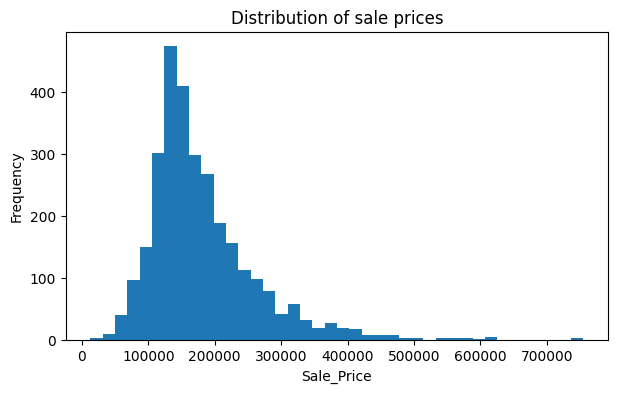

In [8]:
plt.figure(figsize=(7, 4))
plt.hist(ames["Sale_Price"], bins=40)
plt.xlabel("Sale_Price")
plt.ylabel("Frequency")
plt.title("Distribution of sale prices")
plt.show()

In [9]:
ames = ames.copy()
ames["Sale_Price"] = ames["Sale_Price"] / 1000

ames["Sale_Price"].describe()

count    2930.000000
mean      180.796060
std        79.886692
min        12.789000
25%       129.500000
50%       160.000000
75%       213.500000
max       755.000000
Name: Sale_Price, dtype: float64

 The distribution of the variable is asymetrical so we may also consider taking logarithm, but given that it would complicate the interpretation of the results, and that something like normality is not required by the methods we use, only division by 1000 is performed.

In [10]:
ames["Sale_Price"] = ames["Sale_Price"] / 1000

## 4. Train/test split

We split the data into training and test sets. The R lab uses stratified sampling on the numerical response. `train_test_split` cannot directly stratify by a continuous variable, so we create bins of `Sale_Price` and stratify on those bins.

This is not essential for large datasets, but it helps ensure that the training and test sets contain a similar range of prices.

In [11]:
y = ames["Sale_Price"]
X = ames.drop(columns="Sale_Price")

# Create response bins for approximate stratification
price_bins = pd.qcut(y, q=5, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=price_bins
)

X_train.shape, X_test.shape

((2051, 73), (879, 73))

In [12]:
pd.DataFrame({
    "train": y_train.describe(),
    "test": y_test.describe()
})

,train,test
count,2051.000000,879.000000
mean,0.181511,0.179128
std,0.081504,0.075999
min,0.012789,0.039300
25%,0.129875,0.128800
50%,0.161750,0.159000
75%,0.213370,0.214000
max,0.755000,0.625000


## 5. Preprocessing: numerical and categorical variables

Tree-based methods do not require scaling of numerical variables. However, `scikit-learn` cannot directly use string-valued categorical variables in `DecisionTreeRegressor`, `BaggingRegressor`, or `RandomForestRegressor`.

We therefore use:

- numerical predictors: passed through unchanged;
- categorical predictors: one-hot encoded.

This is done inside a `Pipeline`, not manually before the split. This is the recommended workflow because it ensures that the categories are learned from the training set and then applied to the test set. The option `handle_unknown="ignore"` prevents errors if a category appears in the test set but was not present in the training set.

In [13]:
numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()

len(numeric_features), len(categorical_features)

(33, 40)

In [14]:
print("Numerical variables:")
print(numeric_features)
print("\nCategorical variables:")
print(categorical_features)

Numerical variables:
['Lot_Frontage', 'Lot_Area', 'Year_Built', 'Year_Remod_Add', 'Mas_Vnr_Area', 'BsmtFin_SF_1', 'BsmtFin_SF_2', 'Bsmt_Unf_SF', 'Total_Bsmt_SF', 'First_Flr_SF', 'Second_Flr_SF', 'Gr_Liv_Area', 'Bsmt_Full_Bath', 'Bsmt_Half_Bath', 'Full_Bath', 'Half_Bath', 'Bedroom_AbvGr', 'Kitchen_AbvGr', 'TotRms_AbvGrd', 'Fireplaces', 'Garage_Cars', 'Garage_Area', 'Wood_Deck_SF', 'Open_Porch_SF', 'Enclosed_Porch', 'Three_season_porch', 'Screen_Porch', 'Pool_Area', 'Misc_Val', 'Mo_Sold', 'Year_Sold', 'Longitude', 'Latitude']

Categorical variables:
['MS_SubClass', 'MS_Zoning', 'Street', 'Alley', 'Lot_Shape', 'Land_Contour', 'Utilities', 'Lot_Config', 'Land_Slope', 'Neighborhood', 'Condition_1', 'Condition_2', 'Bldg_Type', 'House_Style', 'Overall_Cond', 'Roof_Style', 'Roof_Matl', 'Exterior_1st', 'Exterior_2nd', 'Mas_Vnr_Type', 'Exter_Cond', 'Foundation', 'Bsmt_Cond', 'Bsmt_Exposure', 'BsmtFin_Type_1', 'BsmtFin_Type_2', 'Heating', 'Heating_QC', 'Central_Air', 'Electrical', 'Functional', '

In [15]:
# ColumnTransformer allows us to apply different preprocessing steps
# to different types of variables (e.g. one-hot encoding for categorical
# variables while leaving numerical variables unchanged).

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", make_onehot_encoder(), categorical_features)
    ],
    remainder="drop"
)

## 6. A first regression tree

We start with a relatively small regression tree. This plays the same role as the first, interpretable tree in the R lab.

Because the one-hot encoded data may contain many dummy variables, a completely unrestricted tree can become very large. We therefore control complexity using `max_leaf_nodes`, `min_samples_split`, and `min_samples_leaf`.

In [16]:
small_tree = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_leaf_nodes=12,
        min_samples_split=10,
        min_samples_leaf=5
    ))
])

small_tree.fit(X_train, y_train)

yhat_train_small = small_tree.predict(X_train)
yhat_test_small = small_tree.predict(X_test)

rmse_train_small = rmse(y_train, yhat_train_small)
rmse_test_small = rmse(y_test, yhat_test_small)

rmse_train_small, rmse_test_small

(np.float64(0.04006331231478953), np.float64(0.04053771485439569))

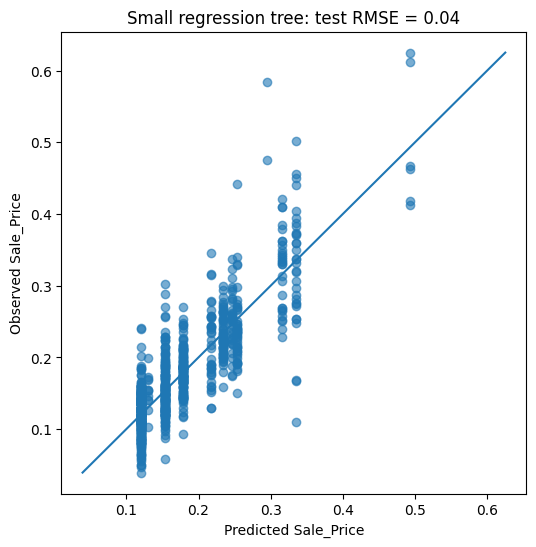

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(yhat_test_small, y_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Predicted Sale_Price")
plt.ylabel("Observed Sale_Price")
plt.title(f"Small regression tree: test RMSE = {rmse_test_small:.2f}")
plt.show()

### Plotting the tree

The plot below is useful for teaching, but it is less readable than the equivalent R plot because one-hot encoding creates variables such as `Neighborhood_North_Ames`. We plot only a small tree for interpretability.

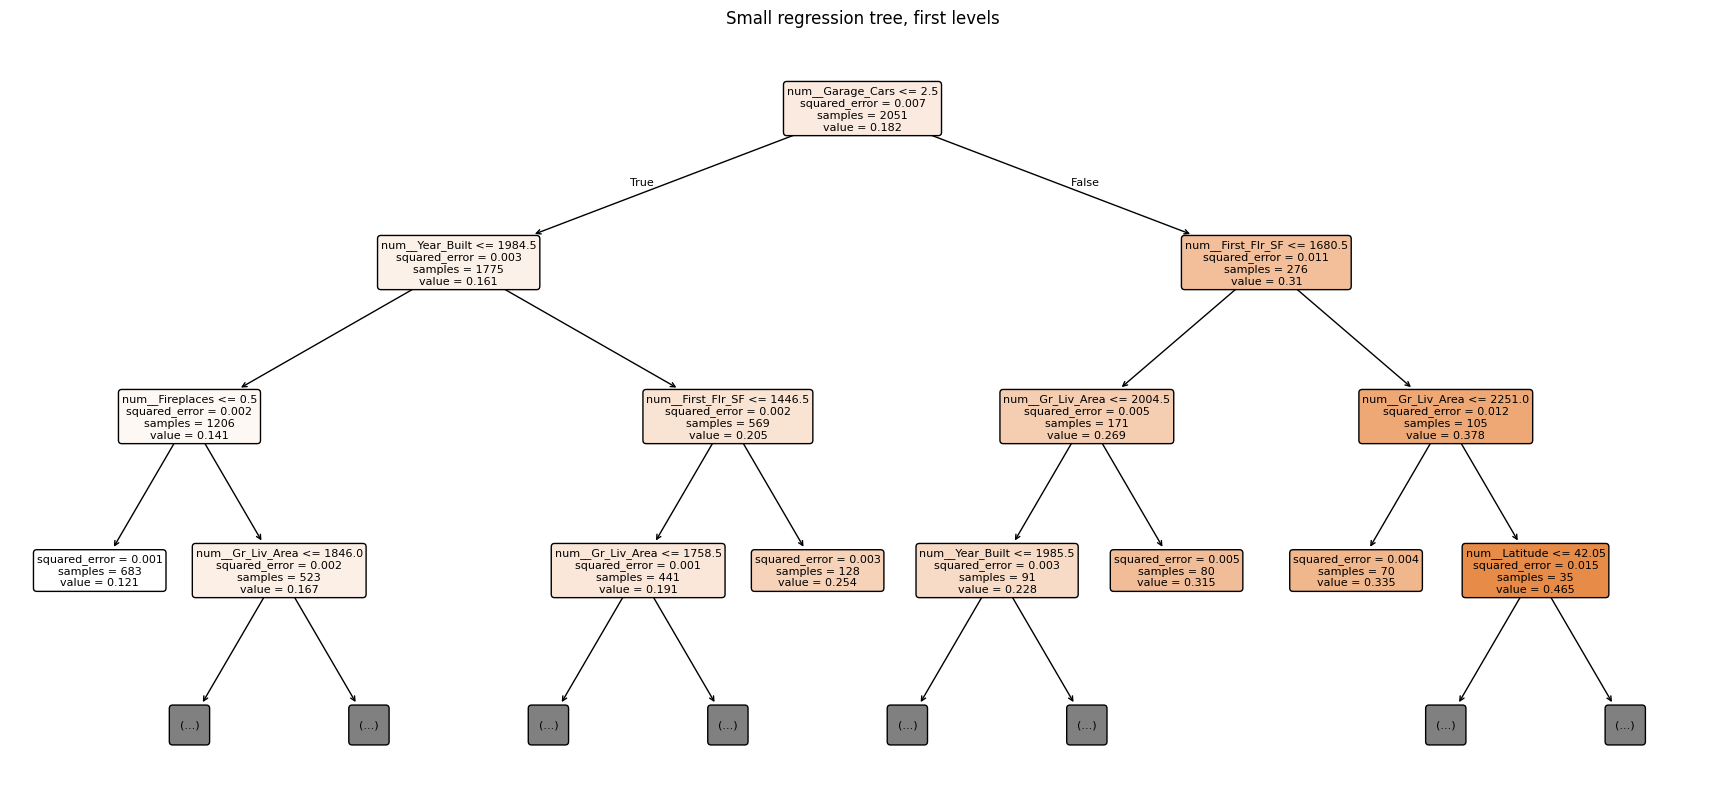

In [18]:
# Recover fitted preprocessing and model objects
fitted_preprocess = small_tree.named_steps["preprocess"]
fitted_tree = small_tree.named_steps["model"]

feature_names = fitted_preprocess.get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(
    fitted_tree,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Small regression tree, first levels")
plt.show()

## 7. A deeper tree

A single decision tree can reduce training error by growing deeper, but this often increases variance and may hurt prediction on new observations. We now fit a much deeper tree.

In [19]:
deep_tree = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        min_samples_split=2,
        min_samples_leaf=1,
        ccp_alpha=0.0
    ))
])

deep_tree.fit(X_train, y_train)

yhat_train_deep = deep_tree.predict(X_train)
yhat_test_deep = deep_tree.predict(X_test)

rmse_train_deep = rmse(y_train, yhat_train_deep)
rmse_test_deep = rmse(y_test, yhat_test_deep)

n_leaves_deep = deep_tree.named_steps["model"].get_n_leaves()
n_nodes_deep = deep_tree.named_steps["model"].tree_.node_count

rmse_train_deep, rmse_test_deep, n_leaves_deep, n_nodes_deep

(np.float64(1.061519644547594e-18),
 np.float64(0.03974869634855408),
 np.int64(1961),
 3921)

The deep tree usually has a much smaller training error. This is expected: a very flexible tree can adapt very closely to the training set. The relevant question is whether this flexibility improves test error.

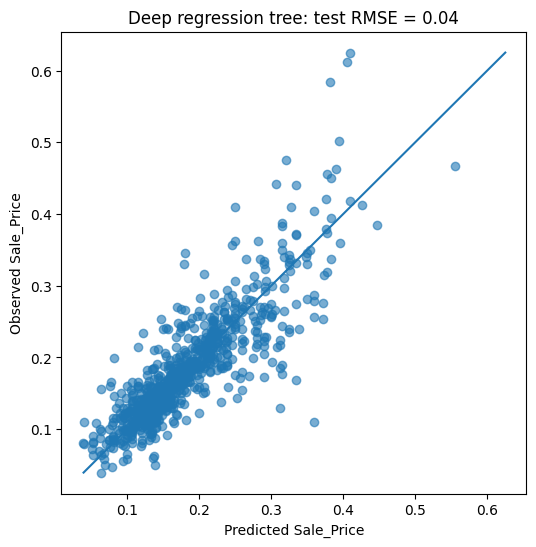

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(yhat_test_deep, y_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Predicted Sale_Price")
plt.ylabel("Observed Sale_Price")
plt.title(f"Deep regression tree: test RMSE = {rmse_test_deep:.2f}")
plt.show()

## 8. Cost-complexity pruning

In CART, pruning can be formulated as minimizing a penalized criterion of the form

$$
R_\alpha(T) = R(T) + \alpha |T|,
$$

where $R(T)$ is the training loss of tree $T$, $|T|$ is a measure of tree size, usually the number of terminal nodes, and $\alpha \geq 0$ controls the penalty for complexity.

In `scikit-learn`, this penalty is controlled by the parameter `ccp_alpha`. Larger values of `ccp_alpha` produce smaller trees.

To choose `ccp_alpha`, we use cross-validation on the training set. The test set is kept only for final assessment.

In [21]:
# First fit the preprocessor on the training set and transform train/test data.
# This is useful for obtaining the cost-complexity pruning path.
preprocess_for_pruning = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", make_onehot_encoder(), categorical_features)
    ],
    remainder="drop"
)

X_train_enc = preprocess_for_pruning.fit_transform(X_train)
X_test_enc = preprocess_for_pruning.transform(X_test)

base_tree_for_path = DecisionTreeRegressor(random_state=RANDOM_STATE)
path = base_tree_for_path.cost_complexity_pruning_path(X_train_enc, y_train)
ccp_alphas = path.ccp_alphas

# Remove the largest alpha, which usually corresponds to the root-only tree
ccp_alphas = ccp_alphas[:-1]
len(ccp_alphas), ccp_alphas[:5], ccp_alphas[-5:]

(1923,
 array([0.00000000e+00, 6.84787910e-13, 9.07118413e-13, 2.43783519e-12,
        2.43783520e-12]),
 array([0.00019159, 0.00019389, 0.00030867, 0.00037756, 0.00077785]))

The pruning path may contain many possible values of `ccp_alpha`. To keep the lab computationally light, we evaluate a representative subset of values.

In [22]:
# Select a manageable grid of alpha values, including zero
if len(ccp_alphas) > 30:
    alpha_grid = np.unique(np.quantile(ccp_alphas, np.linspace(0, 1, 30)))
else:
    alpha_grid = np.unique(ccp_alphas)

alpha_grid = np.unique(np.r_[0, alpha_grid])
alpha_grid[:10], len(alpha_grid)

(array([0.00000000e+00, 3.90053632e-11, 8.12611734e-11, 2.43783520e-10,
        2.97552548e-10, 7.31350561e-10, 9.75134081e-10, 1.52364700e-09,
        2.19405168e-09, 3.46010777e-09]),
 30)

In [23]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pruning_results = []

for alpha in alpha_grid:
    fold_rmse = []
    fold_leaves = []

    for train_idx, valid_idx in cv.split(X_train_enc):
        X_tr, X_val = X_train_enc[train_idx], X_train_enc[valid_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        tree = DecisionTreeRegressor(random_state=RANDOM_STATE, ccp_alpha=alpha)
        tree.fit(X_tr, y_tr)
        pred_val = tree.predict(X_val)

        fold_rmse.append(rmse(y_val, pred_val))
        fold_leaves.append(tree.get_n_leaves())

    pruning_results.append({
        "ccp_alpha": alpha,
        "cv_rmse": np.mean(fold_rmse),
        "cv_rmse_sd": np.std(fold_rmse),
        "mean_leaves": np.mean(fold_leaves)
    })

pruning_results = pd.DataFrame(pruning_results)
pruning_results.sort_values("cv_rmse").head()

,ccp_alpha,cv_rmse,cv_rmse_sd,mean_leaves
28,5.944817e-06,0.041305,0.002595,70.0
27,2.126540e-06,0.042449,0.002462,141.6
26,1.148171e-06,0.042815,0.002204,202.0
25,6.857951e-07,0.042964,0.002749,270.8
24,4.408642e-07,0.043164,0.002575,331.2


In [24]:
best_alpha = pruning_results.loc[pruning_results["cv_rmse"].idxmin(), "ccp_alpha"]
best_alpha

np.float64(5.944817180288091e-06)

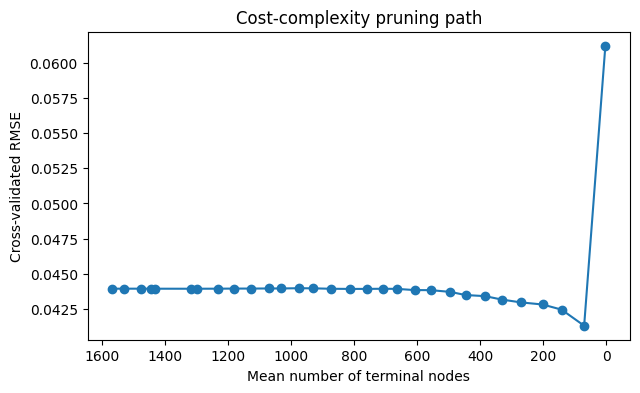

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(pruning_results["mean_leaves"], pruning_results["cv_rmse"], marker="o")
plt.xlabel("Mean number of terminal nodes")
plt.ylabel("Cross-validated RMSE")
plt.title("Cost-complexity pruning path")
plt.gca().invert_xaxis()
plt.show()

In [26]:
pruned_tree = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        ccp_alpha=best_alpha
    ))
])

pruned_tree.fit(X_train, y_train)

yhat_train_pruned = pruned_tree.predict(X_train)
yhat_test_pruned = pruned_tree.predict(X_test)

rmse_train_pruned = rmse(y_train, yhat_train_pruned)
rmse_test_pruned = rmse(y_test, yhat_test_pruned)

n_leaves_pruned = pruned_tree.named_steps["model"].get_n_leaves()

rmse_train_pruned, rmse_test_pruned, n_leaves_pruned

(np.float64(0.023531267305817956),
 np.float64(0.03737819495888696),
 np.int64(70))

## 9. Comparing single-tree models

We collect the results obtained so far. Notice that single trees may be unstable: small changes in the training data can lead to different splits and different trees.

In [27]:
results = pd.DataFrame([
    {"Model": "Small regression tree", "Train RMSE": rmse_train_small, "Test RMSE": rmse_test_small},
    {"Model": "Deep regression tree", "Train RMSE": rmse_train_deep, "Test RMSE": rmse_test_deep},
    {"Model": "Pruned regression tree", "Train RMSE": rmse_train_pruned, "Test RMSE": rmse_test_pruned},
])

results.round(2)

,Model,Train RMSE,Test RMSE
0,Small regression tree,0.04,0.04
1,Deep regression tree,0.00,0.04
2,Pruned regression tree,0.02,0.04


The key lesson is not that one specific tree is always best, but that individual trees tend to have high variance. This motivates ensemble methods.

Bagging reduces variance by averaging predictions over many trees fitted to bootstrap samples of the training data. Random forests add a second source of randomness by considering only a subset of predictors at each split.

## 10. Bagging regression trees

Bagging builds many trees on bootstrap samples of the training data and averages their predictions.

In `scikit-learn`, we can implement bagging explicitly using `BaggingRegressor` with `DecisionTreeRegressor` as the base estimator.

We also request out-of-bag predictions by setting `oob_score=True`. For each training observation, the OOB prediction is obtained by averaging only the trees where that observation was not included in the bootstrap sample.

In [28]:
base_tree = DecisionTreeRegressor(random_state=RANDOM_STATE)

bagging_model = make_bagging_regressor(
    base_tree,
    n_estimators=100,
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

bagging = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", bagging_model)
])

bagging.fit(X_train, y_train)

yhat_train_bag = bagging.predict(X_train)
yhat_test_bag = bagging.predict(X_test)

rmse_train_bag = rmse(y_train, yhat_train_bag)
rmse_test_bag = rmse(y_test, yhat_test_bag)

rmse_train_bag, rmse_test_bag

(np.float64(0.011361892851337207), np.float64(0.02429420369432082))

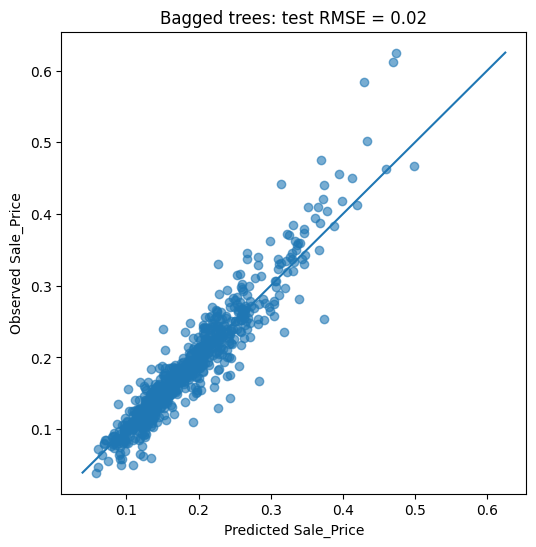

In [29]:
plt.figure(figsize=(6, 6))
plt.scatter(yhat_test_bag, y_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Predicted Sale_Price")
plt.ylabel("Observed Sale_Price")
plt.title(f"Bagged trees: test RMSE = {rmse_test_bag:.2f}")
plt.show()

### Out-of-bag error

The fitted `BaggingRegressor` stores one OOB prediction for each training observation. These predictions behave like predictions on an internal validation set.

They are not computed using the test set. Therefore, the OOB error is useful when we want an estimate of prediction error without setting aside an additional validation sample.

In [30]:
bagging_estimator = bagging.named_steps["model"]
oob_pred_bag = bagging_estimator.oob_prediction_

# In rare cases, an observation may have no OOB prediction if the number of trees is very small.
# With 100 trees this should almost never happen, but we keep the check for safety.
valid_oob = ~np.isnan(oob_pred_bag)
oob_rmse_bag = rmse(y_train.iloc[valid_oob], oob_pred_bag[valid_oob])

oob_rmse_bag, bagging_estimator.oob_score_

(np.float64(0.030139010622225865), 0.8631909493950772)

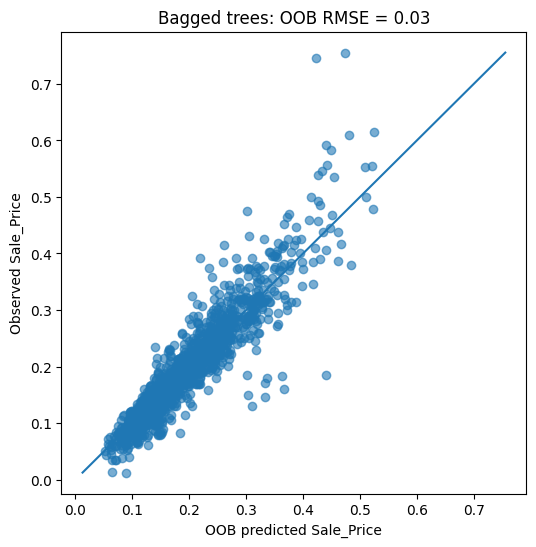

In [31]:
plt.figure(figsize=(6, 6))
plt.scatter(oob_pred_bag[valid_oob], y_train.iloc[valid_oob], alpha=0.6)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()])
plt.xlabel("OOB predicted Sale_Price")
plt.ylabel("Observed Sale_Price")
plt.title(f"Bagged trees: OOB RMSE = {oob_rmse_bag:.2f}")
plt.show()

The training RMSE is usually much smaller than the OOB and test RMSE. This is expected: the fitted ensemble has seen the training observations many times. The OOB error is a more honest internal estimate of prediction error.

## 11. Random forests

A random forest modifies bagging by randomly selecting only a subset of candidate predictors at each split. This tends to reduce correlation between trees, making the average more effective.

In regression, a common default is to consider approximately one third of the predictors at each split. In `scikit-learn`, the default has changed across versions, so we explicitly set `max_features` in the tuning section below. First, we fit a simple random forest with reasonable defaults.

In [32]:
rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=RANDOM_STATE,
        oob_score=True,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)

yhat_train_rf = rf.predict(X_train)
yhat_test_rf = rf.predict(X_test)

rmse_train_rf = rmse(y_train, yhat_train_rf)
rmse_test_rf = rmse(y_test, yhat_test_rf)

rf_estimator = rf.named_steps["model"]
oob_pred_rf = rf_estimator.oob_prediction_
oob_rmse_rf = rmse(y_train, oob_pred_rf)

rmse_train_rf, rmse_test_rf, oob_rmse_rf, rf_estimator.oob_score_

(np.float64(0.011043420348445515),
 np.float64(0.023490217291983587),
 np.float64(0.029718975824794453),
 0.8669776783477551)

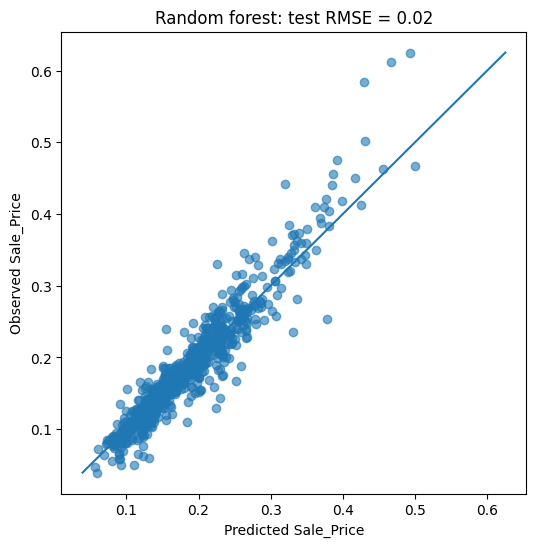

In [33]:
plt.figure(figsize=(6, 6))
plt.scatter(yhat_test_rf, y_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Predicted Sale_Price")
plt.ylabel("Observed Sale_Price")
plt.title(f"Random forest: test RMSE = {rmse_test_rf:.2f}")
plt.show()

## 12. Small grid search for random forests

The two most important tuning parameters here are:

- `n_estimators`: the number of trees;
- `max_features`: the number or proportion of predictors considered at each split.

In Python, after one-hot encoding, the number of input columns can be larger than in the original data. For this reason, using exact values such as 18, 24, or 37 does not have exactly the same meaning as in the R lab. We use proportions instead.

The following grid is deliberately small so that the lab runs in a reasonable time.

In [34]:
rf_for_grid = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        oob_score=False,
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_features": [0.33, 0.50, 1.00]
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=rf_for_grid,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=123, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         'passthrough',
                                                                         ['Lot_Frontage',
                                                                          'Lot_Area',
                                                                          'Year_Built',
                                                                          'Year_Remod_Add',
                                                                          'Mas_Vnr_Area',
                                                                          'BsmtFin_SF_1',
                                                                          'BsmtFin_SF_2',
                                                                          'Bsmt_Unf_SF',
                                                                          'Total_Bsmt_SF',
                                                                          'First_Flr_SF',
                                                                          'Second_Flr_SF',
                                                                          'Gr_Liv_Area',
                                                                          'Bsmt_Full_Bath'...
                                                                          'Foundation',
                                                                          'Bsmt_Cond',
                                                                          'Bsmt_Exposure',
                                                                          'BsmtFin_Type_1',
                                                                          'BsmtFin_Type_2',
                                                                          'Heating',
                                                                          'Heating_QC',
                                                                          'Central_Air',
                                                                          'Electrical', ...])])),
                                       ('model',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=123))]),
             n_jobs=-1,
             param_grid={'model__max_features': [0.33, 0.5, 1.0],
                         'model__n_estimators': [100, 300]},
             return_train_score=True, scoring='neg_root_mean_squared_error')

In [35]:
grid_results = pd.DataFrame(grid.cv_results_)
grid_summary = grid_results[[
    "param_model__n_estimators",
    "param_model__max_features",
    "mean_train_score",
    "mean_test_score",
    "std_test_score"
]].copy()

grid_summary["Train RMSE"] = -grid_summary["mean_train_score"]
grid_summary["CV RMSE"] = -grid_summary["mean_test_score"]
grid_summary["CV RMSE SD"] = grid_summary["std_test_score"]

grid_summary = grid_summary.drop(columns=["mean_train_score", "mean_test_score", "std_test_score"])
grid_summary.sort_values("CV RMSE").round(3)

,param_model__n_estimators,param_model__max_features,Train RMSE,CV RMSE,CV RMSE SD
1,300,0.33,0.011,0.029,0.004
3,300,0.50,0.011,0.029,0.003
2,100,0.50,0.011,0.029,0.003
0,100,0.33,0.011,0.029,0.004
5,300,1.00,0.011,0.030,0.003
4,100,1.00,0.011,0.030,0.003


In [36]:
best_rf = grid.best_estimator_
yhat_test_best_rf = best_rf.predict(X_test)
rmse_test_best_rf = rmse(y_test, yhat_test_best_rf)

grid.best_params_, rmse_test_best_rf

({'model__max_features': 0.33, 'model__n_estimators': 300},
 np.float64(0.023320150432204652))

## 13. Final comparison of models

We now compare all fitted models. The exact numerical values may differ from the R lab, but the general pattern should be similar: ensembles usually reduce test error substantially compared with a single tree.

In [37]:
results = pd.DataFrame([
    {"Model": "Small regression tree", "Train RMSE": rmse_train_small, "Test RMSE": rmse_test_small, "OOB RMSE": np.nan},
    {"Model": "Deep regression tree", "Train RMSE": rmse_train_deep, "Test RMSE": rmse_test_deep, "OOB RMSE": np.nan},
    {"Model": "Pruned regression tree", "Train RMSE": rmse_train_pruned, "Test RMSE": rmse_test_pruned, "OOB RMSE": np.nan},
    {"Model": "Bagged trees", "Train RMSE": rmse_train_bag, "Test RMSE": rmse_test_bag, "OOB RMSE": oob_rmse_bag},
    {"Model": "Random forest", "Train RMSE": rmse_train_rf, "Test RMSE": rmse_test_rf, "OOB RMSE": oob_rmse_rf},
    {"Model": "Random forest, tuned", "Train RMSE": np.nan, "Test RMSE": rmse_test_best_rf, "OOB RMSE": np.nan},
])

results.round(2)

,Model,Train RMSE,Test RMSE,OOB RMSE
0,Small regression tree,0.04,0.04,NaN
1,Deep regression tree,0.00,0.04,NaN
2,Pruned regression tree,0.02,0.04,NaN
3,Bagged trees,0.01,0.02,0.03
4,Random forest,0.01,0.02,0.03
5,"Random forest, tuned",NaN,0.02,NaN


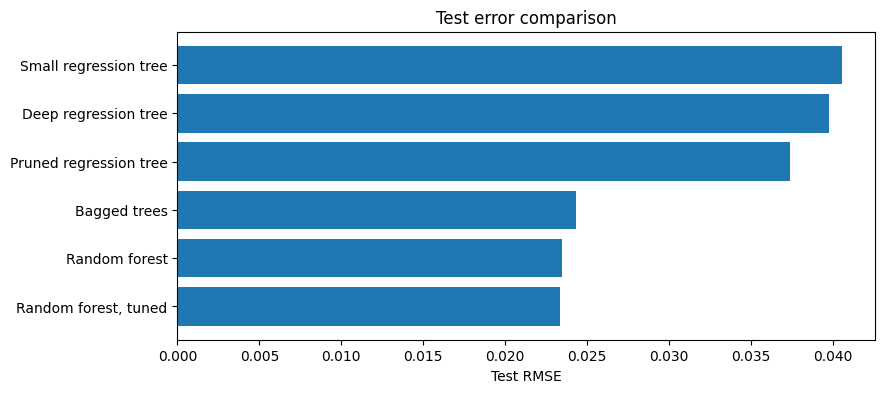

In [38]:
plt.figure(figsize=(9, 4))
plot_data = results.dropna(subset=["Test RMSE"])
plt.barh(plot_data["Model"], plot_data["Test RMSE"])
plt.xlabel("Test RMSE")
plt.title("Test error comparison")
plt.gca().invert_yaxis()
plt.show()

## 14. Variable importance

Tree ensembles provide impurity-based feature importances. In regression trees, this is based on the reduction in squared error attributed to each split.

However, there is an important complication in Python: categorical variables have been one-hot encoded. Therefore, the model sees variables such as:

- `Neighborhood_North_Ames`
- `Neighborhood_Old_Town`
- `House_Style_Two_Story`

rather than the original variables `Neighborhood` and `House_Style`.

For interpretability, we aggregate dummy-level importances back to the original variables.

In [39]:
def get_original_feature_mapping(fitted_preprocessor, numeric_features, categorical_features):
    """Return transformed feature names and their corresponding original feature names."""
    feature_names = []
    original_names = []

    # Numerical variables
    for col in numeric_features:
        feature_names.append(f"num__{col}")
        original_names.append(col)

    # Categorical variables
    encoder = fitted_preprocessor.named_transformers_["cat"]
    for col, categories in zip(categorical_features, encoder.categories_):
        for cat in categories:
            feature_names.append(f"cat__{col}_{cat}")
            original_names.append(col)

    return np.array(feature_names), np.array(original_names)


def aggregate_importances_by_original_variable(fitted_pipeline, importances, numeric_features, categorical_features):
    fitted_preprocessor = fitted_pipeline.named_steps["preprocess"]
    transformed_names, original_names = get_original_feature_mapping(
        fitted_preprocessor, numeric_features, categorical_features
    )

    # Safety check: use actual transformed names if lengths differ
    actual_names = fitted_preprocessor.get_feature_names_out()
    if len(original_names) != len(importances):
        raise ValueError(
            f"Length mismatch: {len(original_names)} original names vs {len(importances)} importances."
        )

    out = pd.DataFrame({
        "transformed_feature": actual_names,
        "original_feature": original_names,
        "importance": importances
    })

    grouped = (
        out.groupby("original_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )

    return grouped, out

### Random forest variable importance

In [40]:
rf_importances = rf.named_steps["model"].feature_importances_
rf_grouped_importance, rf_dummy_importance = aggregate_importances_by_original_variable(
    rf, rf_importances, numeric_features, categorical_features
)

rf_grouped_importance.head(20)

,original_feature,importance
27,Garage_Cars,0.371413
31,Gr_Liv_Area,0.143674
70,Year_Built,0.107454
22,First_Flr_SF,0.064435
67,Total_Bsmt_SF,0.063988
71,Year_Remod_Add,0.029570
21,Fireplaces,0.021762
41,Lot_Area,0.017548
39,Latitude,0.015438
24,Full_Bath,0.012567


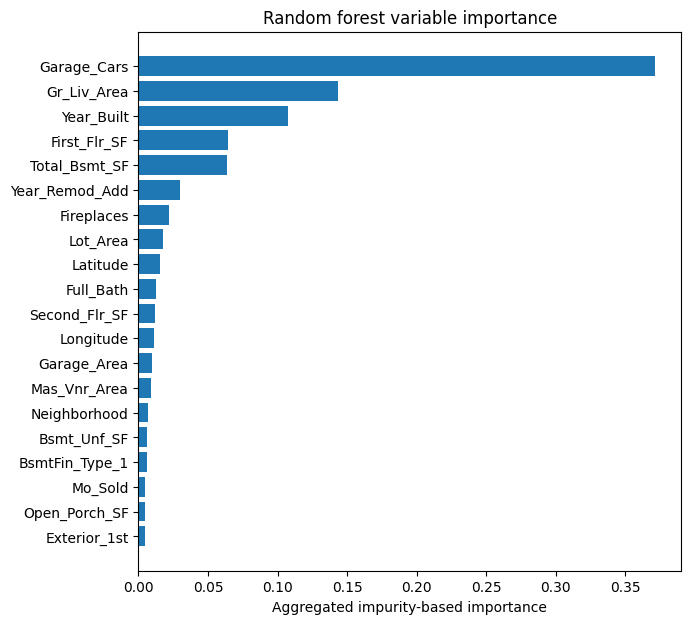

In [41]:
top_rf = rf_grouped_importance.head(20).sort_values("importance")

plt.figure(figsize=(7, 7))
plt.barh(top_rf["original_feature"], top_rf["importance"])
plt.xlabel("Aggregated impurity-based importance")
plt.title("Random forest variable importance")
plt.show()

### Bagging variable importance

`BaggingRegressor` does not directly provide a single `feature_importances_` vector, because the ensemble is a collection of separate decision trees. We can approximate the ensemble importance by averaging the feature importances of all individual trees.

In [42]:
bagging_estimator = bagging.named_steps["model"]

bag_importances = np.mean(
    [est.feature_importances_ for est in bagging_estimator.estimators_],
    axis=0
)

bag_grouped_importance, bag_dummy_importance = aggregate_importances_by_original_variable(
    bagging, bag_importances, numeric_features, categorical_features
)

bag_grouped_importance.head(20)

,original_feature,importance
27,Garage_Cars,0.379936
31,Gr_Liv_Area,0.140384
70,Year_Built,0.110295
22,First_Flr_SF,0.064934
67,Total_Bsmt_SF,0.059072
71,Year_Remod_Add,0.027186
21,Fireplaces,0.023954
41,Lot_Area,0.017895
39,Latitude,0.014137
63,Second_Flr_SF,0.012463


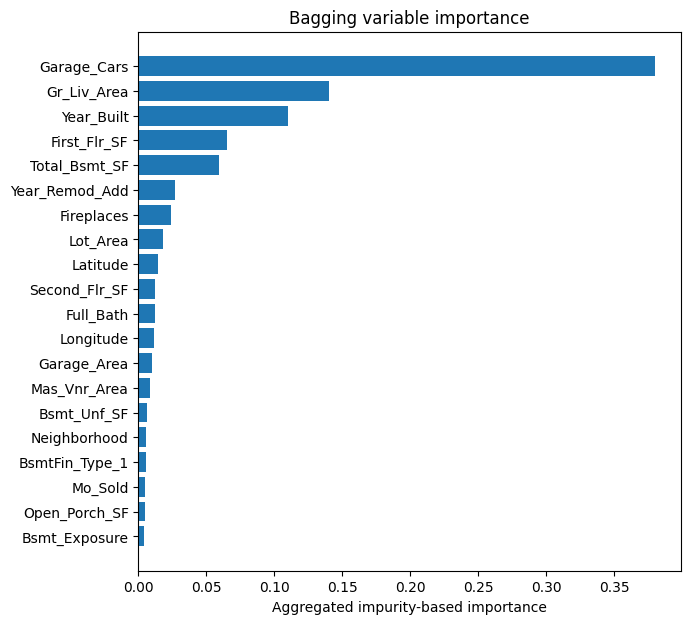

In [43]:
top_bag = bag_grouped_importance.head(20).sort_values("importance")

plt.figure(figsize=(7, 7))
plt.barh(top_bag["original_feature"], top_bag["importance"])
plt.xlabel("Aggregated impurity-based importance")
plt.title("Bagging variable importance")
plt.show()

## 15. Interpretation and final remarks

This lab illustrates the same statistical learning ideas as the R version, but in the Python ecosystem.

The most important methodological points are:

1. **Single trees are interpretable but unstable.** They can be useful for understanding the structure of the problem, but their predictive performance is often limited.
2. **Growing deeper trees reduces training error**, but this does not necessarily improve test error.
3. **Cost-complexity pruning** controls the trade-off between tree fit and tree size.
4. **Bagging reduces variance** by averaging many high-variance trees trained on bootstrap samples.
5. **Out-of-bag predictions** provide an internal estimate of prediction error without using the test set.
6. **Random forests improve bagging** by decorrelating trees through random feature selection at each split.
7. **Preprocessing matters in Python.** Categorical variables must be encoded, and this should be done inside a `Pipeline`.
8. **Variable importance must be interpreted carefully after one-hot encoding.** It is often more meaningful to aggregate dummy-level importances back to the original variables.

In practice, random forests often work well with little tuning, which is why they are commonly described as strong out-of-the-box predictors. Still, careful validation is essential, and test-set performance should be the main criterion for comparing final models.

# Questions

1. Compare the test RMSE obtained with:
   - a single regression tree,
   - Bagging,
   - and Random Forests.

   Which method achieves the best predictive performance on the Ames Housing dataset?

2. Inspect the selected value of `mtry` (R) or `max_features` (Python).
   
   - What value was selected?
   - How does it compare with the total number of predictors?

3. Increase the number of trees (`ntree` in R or `n_estimators` in Python) from 100 to 1000.
   
   - Does the test RMSE improve substantially?
   - Does computation time increase noticeably?

4. Identify the 10 most important variables according to the Random Forest model.
   
   - Are these variables reasonable from a real-estate perspective?
   - Do the same variables appear important in both R and Python?

5. Compare the variable importance obtained using:
   
   - impurity-based importance,
   - and permutation importance (if available).

   Do both approaches rank variables similarly?

6. Modify the Random Forest model so that only numerical predictors are used.
   
   - Does predictive performance decrease?
   - Which categorical variables seem most informative in the original model?

7. Train a Random Forest using only the 10 most important predictors identified previously.
   
   - How much predictive performance is lost compared with the full model?

8. Compare the training RMSE and the test RMSE for:
   
   - a single tree,
   - Bagging,
   - and Random Forests.

   Which model appears to overfit the most?

9. Change the value of `max_features` (`mtry`) manually:
   
   - try a very small value,
   - and a very large value.

   How does this affect:
   
   - test RMSE,
   - and the correlation between trees?

10. Examine the Out-Of-Bag (OOB) error estimate.
    
    - How similar is the OOB error to the test error?
    - Why can OOB error be useful in practice?

11. Repeat the train/test split using a different random seed.
    
    - Are the results stable?
    - Which model appears most robust to changes in the split?

12. Compare the execution time of:
    
    - a single regression tree,
    - Bagging,
    - and Random Forests.

    Is the improvement in predictive performance worth the additional computational cost?

13. Visualize the predictions versus observed values for the Random Forest model.
    
    - Are prediction errors approximately homogeneous?
    - Do you observe systematic underestimation or overestimation for expensive houses?

14. In the Python notebook, inspect the effect of `OneHotEncoder`.
    
    - How many predictors are generated after preprocessing?
    - Why is this transformation necessary in `scikit-learn`?

15. Compare the Random Forest implementation in R and Python.
    
    - Are the results identical?
    - Which implementation is easier to interpret or customize?
